1) Importing & configuration

In [85]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns


DATA_PATH = 'features_stats_only.csv'
RANDOM_STATE = 42
N_SPLITS = 5

print(f"Constants defined: RANDOM_STATE={RANDOM_STATE}, N_SPLITS={N_SPLITS}")


from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.inspection import permutation_importance




print("--- Step 1: Load All Libraries & Prepare Data ---")
print("All libraries imported successfully.")



Constants defined: RANDOM_STATE=42, N_SPLITS=5
--- Step 1: Load All Libraries & Prepare Data ---
All libraries imported successfully.


In [86]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Columns (first 10): {list(df.columns[:10])} ...")

print("\nTarget distribution (y_over25):")
print(df["y_over25"].value_counts(normalize=True).round(3))

print("\nSeasons:", df["season"].nunique())
print("Leagues:", df["league"].nunique())
print("Countries:", df["country"].nunique())

print("\nMissing values (columns with any):")
missing = df.isna().sum()
print(missing[missing > 0])

print("\nDtypes (first 20):")
print(df.dtypes.head(20))

Rows: 42593 | Columns: 59
Columns (first 10): ['Div', 'kickoff_dt', 'HomeTeam', 'AwayTeam', 'season', 'month', 'weekday', 'is_weekend', 'y_over25', 'home_rest_days'] ...

Target distribution (y_over25):
y_over25
0    0.5
1    0.5
Name: proportion, dtype: float64

Seasons: 6
Leagues: 4
Countries: 11

Missing values (columns with any):
home_ppg_5                   308
home_gf_mean_5               308
home_ga_mean_5               308
home_gd_mean_5               308
home_gd_std_5                616
home_total_goals_mean_5      308
home_away_win_rate_5       42593
home_ppg_season             1152
home_gf_season              1152
home_ga_season              1152
home_league_avg_goals         68
away_ppg_5                   324
away_gf_mean_5               324
away_ga_mean_5               324
away_gd_mean_5               324
away_gd_std_5                648
away_total_goals_mean_5      324
away_home_win_rate_5       42593
away_ppg_season             1145
away_gf_season              1145
away

In [87]:
df["kickoff_dt"] = pd.to_datetime(df["kickoff_dt"], utc=True, errors="raise")
print("\n'kickoff_dt' converted to datetime (UTC).")

# Drop empty columns
cols_to_drop = [
    'home_away_win_rate_5',
    'away_home_win_rate_5',
    'diff_home_win_rate_5',
    'diff_away_win_rate_5'
]
df = df.drop(columns=cols_to_drop)

numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('y_over25', errors='ignore')
df[numeric_cols] = df[numeric_cols].fillna(0)


df = df.sort_values(by='kickoff_dt')
df = df.reset_index(drop=True)


y = df['y_over25']
X = df.select_dtypes(include=np.number).drop(columns=['y_over25'])

print(f"\nTarget 'y' shape: {y.shape}")
print(f"Features 'X' shape: {X.shape} (All features)")
print(f"Total features being used: {len(X.columns)}")

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
print(f"Cross-Validation strategy: TimeSeriesSplit with {N_SPLITS} splits.")

models_to_test = {
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')
}
print(f"Models to be tested: {list(models_to_test.keys())}")

output_path = 'results'



'kickoff_dt' converted to datetime (UTC).

Target 'y' shape: (42593,)
Features 'X' shape: (42593, 49) (All features)
Total features being used: 49
Cross-Validation strategy: TimeSeriesSplit with 5 splits.
Models to be tested: ['RandomForest', 'XGBoost']


Experiment 1: Training on All 49 Features

In [88]:


experiment_1_results = []
feature_importances = {}

metrics_to_calc = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "F1_Score": f1_score,
    "ROC_AUC": roc_auc_score,
    "Brier_Score": brier_score_loss
}

for model_name, model in models_to_test.items():
    print(f"\n--- Testing Model: {model_name} ---")
    start_time = time.time()

    fold_metrics = []

    for fold_idx, (train_index, test_index) in enumerate(tscv.split(X)):
        print(f"  Fold {fold_idx+1}/{N_SPLITS}...")

        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        current_model = model.__class__(**model.get_params())

        current_model.fit(X_train, y_train)

        y_pred = current_model.predict(X_test)
        y_prob = current_model.predict_proba(X_test)[:, 1]

        fold_results = {"model": model_name, "fold": fold_idx+1}
        for metric_name, metric_func in metrics_to_calc.items():
            try:
                if metric_name in ["ROC_AUC", "Brier_Score"]:
                    score = metric_func(y_test, y_prob)
                else:
                    score = metric_func(y_test, y_pred)
                fold_results[metric_name] = score
            except Exception as e:
                print(f"    Could not calculate {metric_name}: {e}")
                fold_results[metric_name] = np.nan

        fold_metrics.append(fold_results)


        if fold_idx == N_SPLITS - 1:
            if hasattr(current_model, 'feature_importances_'):
                print(f"  Saving feature importances for {model_name}...")
                importances_df = pd.DataFrame({
                    'feature': X.columns,
                    'importance': current_model.feature_importances_
                }).sort_values(by='importance', ascending=False)

                feature_importances[model_name] = importances_df

    fold_metrics_df = pd.DataFrame(fold_metrics)


    mean_metrics = fold_metrics_df.mean(numeric_only=True)
    std_metrics = fold_metrics_df.std(numeric_only=True)

    print(f"  Done in {time.time() - start_time:.2f}s")
    print(f"  Avg. ROC_AUC: {mean_metrics['ROC_AUC']:.4f} (+/- {std_metrics['ROC_AUC']:.4f})")


    avg_results_row = {"model": model_name, "feature_set": "all_49"}
    for metric_name in metrics_to_calc.keys():
        avg_results_row[f"{metric_name}_mean"] = mean_metrics.get(metric_name, np.nan)
        avg_results_row[f"{metric_name}_std"] = std_metrics.get(metric_name, np.nan)

    experiment_1_results.append(avg_results_row)


print("\n--- Experiment 1: Summary (All Features) ---")
exp1_results_df = pd.DataFrame(experiment_1_results)


columns_to_show = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_calc.keys()]
print(exp1_results_df[columns_to_show].to_markdown(index=False, floatfmt=".4f"))


exp1_csv_path = os.path.join(output_path, 'experiment_1_all_features.csv')
exp1_results_df.to_csv(exp1_csv_path, index=False)
print(f"\nExperiment 1 results saved to: {exp1_csv_path}")


for model_name, importance_df in feature_importances.items():
    importance_csv_path = os.path.join(output_path, f'feature_importance_{model_name}.csv')
    importance_df.to_csv(importance_csv_path, index=False)
    print(f"Feature importance for {model_name} saved to: {importance_csv_path}")
    print(f"\nTop 10 features for {model_name}:")
    print(importance_df.head(10).to_markdown(index=False, floatfmt=".6f"))




--- Testing Model: RandomForest ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for RandomForest...
  Done in 53.60s
  Avg. ROC_AUC: 0.5837 (+/- 0.0127)

--- Testing Model: XGBoost ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for XGBoost...
  Done in 5.35s
  Avg. ROC_AUC: 0.5916 (+/- 0.0109)

--- Experiment 1: Summary (All Features) ---
| model        | feature_set   |   Accuracy_mean |   Precision_mean |   Recall_mean |   F1_Score_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:-------------|:--------------|----------------:|-----------------:|--------------:|----------------:|---------------:|-------------------:|
| RandomForest | all_49        |          0.5558 |           0.5638 |        0.4893 |          0.5238 |         0.5837 |             0.2429 |
| XGBoost      | all_49        |          0.5614 |           0.5656 |        0.5272 |          0.5454 |         0.5916 | 

Experiment 2: Training on Top 10 XGBoost Features


In [89]:

top_10_xgb_features = [
    'diff_league_avg_goals',
    'home_league_avg_goals',
    'month',
    'away_league_avg_goals',
    'home_gf_season',
    'league',
    'away_ppg_season',
    'diff_ppg_season',
    'away_loss_rate_5',
    'diff_gf_season'
]

X_exp2 = X[top_10_xgb_features]

print(f"Features 'X_exp2' shape: {X_exp2.shape} (Top 10 features)")

experiment_2_results = []
feature_importances_exp2 = {}

for model_name, model in models_to_test.items():
    print(f"\n--- Testing Model: {model_name} (on Top 10) ---")
    start_time = time.time()

    fold_metrics = []

    for fold_idx, (train_index, test_index) in enumerate(tscv.split(X_exp2)):
        print(f"  Fold {fold_idx+1}/{N_SPLITS}...")

        X_train, X_test = X_exp2.iloc[train_index], X_exp2.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        current_model = model.__class__(**model.get_params())

        current_model.fit(X_train, y_train)

        y_pred = current_model.predict(X_test)
        y_prob = current_model.predict_proba(X_test)[:, 1]

        fold_results = {"model": model_name, "fold": fold_idx+1}
        for metric_name, metric_func in metrics_to_calc.items():
            try:
                if metric_name in ["ROC_AUC", "Brier_Score"]:
                    score = metric_func(y_test, y_prob)
                else:
                    score = metric_func(y_test, y_pred)
                fold_results[metric_name] = score
            except Exception as e:
                print(f"    Could not calculate {metric_name}: {e}")
                fold_results[metric_name] = np.nan

        fold_metrics.append(fold_results)


        if fold_idx == N_SPLITS - 1:
            if hasattr(current_model, 'feature_importances_'):
                print(f"  Saving feature importances for {model_name} (Exp 2)...")
                importances_df = pd.DataFrame({
                    'feature': X_exp2.columns,
                    'importance': current_model.feature_importances_
                }).sort_values(by='importance', ascending=False)

                feature_importances_exp2[model_name] = importances_df

    fold_metrics_df = pd.DataFrame(fold_metrics)


    mean_metrics = fold_metrics_df.mean(numeric_only=True)
    std_metrics = fold_metrics_df.std(numeric_only=True)

    print(f"  Done in {time.time() - start_time:.2f}s")
    print(f"  Avg. ROC_AUC: {mean_metrics['ROC_AUC']:.4f} (+/- {std_metrics['ROC_AUC']:.4f})")

    avg_results_row = {"model": model_name, "feature_set": "top_10_xgb"}
    for metric_name in metrics_to_calc.keys():
        avg_results_row[f"{metric_name}_mean"] = mean_metrics.get(metric_name, np.nan)
        avg_results_row[f"{metric_name}_std"] = std_metrics.get(metric_name, np.nan)

    experiment_2_results.append(avg_results_row)


print("\n--- Experiment 2: Summary (Top 10 Features) ---")
exp2_results_df = pd.DataFrame(experiment_2_results)


columns_to_show = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_calc.keys()]
print(exp2_results_df[columns_to_show].to_markdown(index=False, floatfmt=".4f"))


exp2_csv_path = os.path.join(output_path, 'experiment_2_top10_features.csv')
exp2_results_df.to_csv(exp2_csv_path, index=False)
print(f"\nExperiment 2 results saved to: {exp2_csv_path}")


for model_name, importance_df in feature_importances_exp2.items():
    importance_csv_path = os.path.join(output_path, f'feature_importance_{model_name}_exp2.csv')
    importance_df.to_csv(importance_csv_path, index=False)
    print(f"Feature importance for {model_name} (Exp 2) saved to: {importance_csv_path}")
    print(f"\nTop 10 features for {model_name} (Exp 2):")
    print(importance_df.head(10).to_markdown(index=False, floatfmt=".6f"))



Features 'X_exp2' shape: (42593, 10) (Top 10 features)

--- Testing Model: RandomForest (on Top 10) ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for RandomForest (Exp 2)...
  Done in 36.89s
  Avg. ROC_AUC: 0.6001 (+/- 0.0083)

--- Testing Model: XGBoost (on Top 10) ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for XGBoost (Exp 2)...
  Done in 2.02s
  Avg. ROC_AUC: 0.6032 (+/- 0.0160)

--- Experiment 2: Summary (Top 10 Features) ---
| model        | feature_set   |   Accuracy_mean |   Precision_mean |   Recall_mean |   F1_Score_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:-------------|:--------------|----------------:|-----------------:|--------------:|----------------:|---------------:|-------------------:|
| RandomForest | top_10_xgb    |          0.5690 |           0.5825 |        0.4811 |          0.5266 |         0.6001 |             0.2403 |
| XGBoost      | top_10

Experiment 3: Training on Top 10 RandomForest Features

In [90]:

top_10_rf_features = [
    'diff_league_avg_goals',
    'away_league_avg_goals',
    'home_league_avg_goals',
    'diff_gd_std_5',
    'home_gf_season',
    'diff_gf_season',
    'diff_ga_season',
    'diff_ppg_season',
    'away_gf_season',
    'away_ga_season'
]

X_exp3 = X[top_10_rf_features]

print(f"Features 'X_exp3' shape: {X_exp3.shape} (Top 10 RF features)")

experiment_3_results = []
feature_importances_exp3 = {}

for model_name, model in models_to_test.items():
    print(f"\n--- Testing Model: {model_name} (on Top 10 RF) ---")
    start_time = time.time()

    fold_metrics = []

    for fold_idx, (train_index, test_index) in enumerate(tscv.split(X_exp3)):
        print(f"  Fold {fold_idx+1}/{N_SPLITS}...")

        X_train, X_test = X_exp3.iloc[train_index], X_exp3.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        current_model = model.__class__(**model.get_params())

        current_model.fit(X_train, y_train)

        y_pred = current_model.predict(X_test)
        y_prob = current_model.predict_proba(X_test)[:, 1]

        fold_results = {"model": model_name, "fold": fold_idx+1}
        for metric_name, metric_func in metrics_to_calc.items():
            try:
                if metric_name in ["ROC_AUC", "Brier_Score"]:
                    score = metric_func(y_test, y_prob)
                else:
                    score = metric_func(y_test, y_pred)
                fold_results[metric_name] = score
            except Exception as e:
                print(f"    Could not calculate {metric_name}: {e}")
                fold_results[metric_name] = np.nan

        fold_metrics.append(fold_results)


        if fold_idx == N_SPLITS - 1:
            if hasattr(current_model, 'feature_importances_'):
                print(f"  Saving feature importances for {model_name} (Exp 3)...")
                importances_df = pd.DataFrame({
                    'feature': X_exp3.columns,
                    'importance': current_model.feature_importances_
                }).sort_values(by='importance', ascending=False)

                feature_importances_exp3[model_name] = importances_df

    fold_metrics_df = pd.DataFrame(fold_metrics)


    mean_metrics = fold_metrics_df.mean(numeric_only=True)
    std_metrics = fold_metrics_df.std(numeric_only=True)

    print(f"  Done in {time.time() - start_time:.2f}s")
    print(f"  Avg. ROC_AUC: {mean_metrics['ROC_AUC']:.4f} (+/- {std_metrics['ROC_AUC']:.4f})")

    avg_results_row = {"model": model_name, "feature_set": "top_10_rf"}
    for metric_name in metrics_to_calc.keys():
        avg_results_row[f"{metric_name}_mean"] = mean_metrics.get(metric_name, np.nan)
        avg_results_row[f"{metric_name}_std"] = std_metrics.get(metric_name, np.nan)

    experiment_3_results.append(avg_results_row)


print("\n--- Experiment 3: Summary (Top 10 RF Features) ---")
exp3_results_df = pd.DataFrame(experiment_3_results)


columns_to_show = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_calc.keys()]
print(exp3_results_df[columns_to_show].to_markdown(index=False, floatfmt=".4f"))


exp3_csv_path = os.path.join(output_path, 'experiment_3_top10_rf_features.csv')
exp3_results_df.to_csv(exp3_csv_path, index=False)
print(f"\nExperiment 3 results saved to: {exp3_csv_path}")


for model_name, importance_df in feature_importances_exp3.items():
    importance_csv_path = os.path.join(output_path, f'feature_importance_{model_name}_exp3.csv')
    importance_df.to_csv(importance_csv_path, index=False)
    print(f"Feature importance for {model_name} (Exp 3) saved to: {importance_csv_path}")
    print(f"\nTop 10 features for {model_name} (Exp 3):")
    print(importance_df.head(10).to_markdown(index=False, floatfmt=".6f"))



Features 'X_exp3' shape: (42593, 10) (Top 10 RF features)

--- Testing Model: RandomForest (on Top 10 RF) ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for RandomForest (Exp 3)...
  Done in 46.31s
  Avg. ROC_AUC: 0.5920 (+/- 0.0134)

--- Testing Model: XGBoost (on Top 10 RF) ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Saving feature importances for XGBoost (Exp 3)...
  Done in 2.91s
  Avg. ROC_AUC: 0.5859 (+/- 0.0135)

--- Experiment 3: Summary (Top 10 RF Features) ---
| model        | feature_set   |   Accuracy_mean |   Precision_mean |   Recall_mean |   F1_Score_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:-------------|:--------------|----------------:|-----------------:|--------------:|----------------:|---------------:|-------------------:|
| RandomForest | top_10_rf     |          0.5606 |           0.5737 |        0.4690 |          0.5158 |         0.5920 |             0.2421 |
| XGBoost  

Model and features comparison

In [91]:
output_path = 'results'

exp_files = [
    'experiment_1_all_features.csv',
    'experiment_2_top10_features.csv',
    'experiment_3_top10_rf_features.csv'
]

all_results_df_list = []
for file in exp_files:
  file_path = os.path.join(output_path, file)
  df = pd.read_csv(file_path)
  all_results_df_list.append(df)

baseline_data_list = [
    {
        'model': 'LinearSVM (Baseline)',
        'feature_set': 'baseline_CV',
        'Accuracy_mean': 0.553,
        'ROC_AUC_mean': 0.573, # Best baseline
        'Brier_Score_mean': 0.247,
    },
    {
        'model': 'RandomForest (Baseline)',
        'feature_set': 'baseline_CV',
        'Accuracy_mean': 0.548,
        'ROC_AUC_mean': 0.569,
        'Brier_Score_mean': 0.248,
    }
]
baseline_df = pd.DataFrame(baseline_data_list)
all_results_df_list.append(baseline_df)

print("\nConcatenating all results...")
final_summary_df = pd.concat(all_results_df_list, ignore_index=True)

metrics_to_show = ["Accuracy", "ROC_AUC", "Brier_Score"]
columns_to_display = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_show]

# Make sure all columns exist
for col in columns_to_display:
    if col not in final_summary_df.columns:
        final_summary_df[col] = np.nan

final_summary_df = final_summary_df.sort_values(by='ROC_AUC_mean', ascending=False)

print("\n--- Final Ranking (incl. Baseline) ---")
print(final_summary_df[columns_to_display].to_markdown(index=False, floatfmt=".4f"))

final_csv_path = os.path.join(output_path, 'final_summary_all_experiments_with_baseline.csv')
final_summary_df.to_csv(final_csv_path, index=False)


Concatenating all results...

--- Final Ranking (incl. Baseline) ---
| model                   | feature_set   |   Accuracy_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:------------------------|:--------------|----------------:|---------------:|-------------------:|
| XGBoost                 | top_10_xgb    |          0.5695 |         0.6032 |             0.2473 |
| RandomForest            | top_10_xgb    |          0.5690 |         0.6001 |             0.2403 |
| RandomForest            | top_10_rf     |          0.5606 |         0.5920 |             0.2421 |
| XGBoost                 | all_49        |          0.5614 |         0.5916 |             0.2542 |
| XGBoost                 | top_10_rf     |          0.5566 |         0.5859 |             0.2518 |
| RandomForest            | all_49        |          0.5558 |         0.5837 |             0.2429 |
| LinearSVM (Baseline)    | baseline_CV   |          0.5530 |         0.5730 |             0.2470 |
| RandomForest (Baseline) | ba

Feature engineering


In [92]:
xgb_base = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss',
    )

param_distributions = {
        'n_estimators': [100, 200, 300, 500, 700],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }


random_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_distributions,
        n_iter=25,
        scoring='roc_auc',
        n_jobs=-1,
        cv=tscv,
        verbose=2,
        random_state=RANDOM_STATE
    )

start_time = time.time()

random_search.fit(X_exp2, y)

end_time = time.time()
print(f"\n--- Tuning finished in {end_time - start_time:.2f}s ---")


print(f"\nBest score found (ROC_AUC): {random_search.best_score_:.4f}")

print("\nBest parameters (best_params_):")
best_params = random_search.best_params_
for param, value in best_params.items():
        print(f"  {param}: {value}")


best_params_df = pd.DataFrame([best_params])
params_csv_path = os.path.join(output_path, 'best_xgb_hyperparameters.csv')
best_params_df.to_csv(params_csv_path, index=False)


Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- Tuning finished in 206.25s ---

Best score found (ROC_AUC): 0.6217

Best parameters (best_params_):
  subsample: 0.9
  n_estimators: 200
  max_depth: 10
  learning_rate: 0.01
  colsample_bytree: 0.9


In [93]:
print("\n\n--- Experiment 5: Final Validation of Tuned XGBoost ---")


best_params_from_exp4 = {
    'subsample': 0.9,
    'n_estimators': 200,
    'max_depth': 10,
    'learning_rate': 0.01,
    'colsample_bytree': 0.9
}


xgb_tuned_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    **best_params_from_exp4
)

models_to_test_exp5 = {
    "XGBoost_Tuned": xgb_tuned_model
}

experiment_5_results = []
for model_name, model in models_to_test_exp5.items():
        print(f"\n--- Testing Model: {model_name} ---")
        start_time = time.time()

fold_metrics = []

for fold_idx, (train_index, test_index) in enumerate(tscv.split(X_exp2)):
  print(f"  Fold {fold_idx+1}/{N_SPLITS}...")

X_train, X_test = X_exp2.iloc[train_index], X_exp2.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

current_model = model.__class__(**model.get_params())

current_model.fit(X_train, y_train)

y_pred = current_model.predict(X_test)
y_prob = current_model.predict_proba(X_test)[:, 1]

fold_results = {"model": model_name, "fold": fold_idx+1}
for metric_name, metric_func in metrics_to_calc.items():
                try:
                    if metric_name in ["ROC_AUC", "Brier_Score"]:
                        score = metric_func(y_test, y_prob)
                    else:
                        score = metric_func(y_test, y_pred)
                    fold_results[metric_name] = score
                except Exception as e:
                    print(f"    Could not calculate {metric_name}: {e}")
                    fold_results[metric_name] = np.nan

fold_metrics.append(fold_results)

fold_metrics_df = pd.DataFrame(fold_metrics)
mean_metrics = fold_metrics_df.mean(numeric_only=True)
std_metrics = fold_metrics_df.std(numeric_only=True)

print(f"  Done in {time.time() - start_time:.2f}s")
print(f"  Avg. ROC_AUC: {mean_metrics['ROC_AUC']:.4f} (+/- {std_metrics['ROC_AUC']:.4f})")

avg_results_row = {"model": model_name, "feature_set": "top_10_xgb_tuned"}
for metric_name in metrics_to_calc.keys():
  avg_results_row[f"{metric_name}_mean"] = mean_metrics.get(metric_name, np.nan)
  avg_results_row[f"{metric_name}_std"] = std_metrics.get(metric_name, np.nan)

experiment_5_results.append(avg_results_row)

print("\n--- Experiment 5: Summary (Tuned Model) ---")
exp5_results_df = pd.DataFrame(experiment_5_results)

columns_to_show = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_calc.keys()]
print(exp5_results_df[columns_to_show].to_markdown(index=False, floatfmt=".4f"))

exp5_csv_path = os.path.join(output_path, 'experiment_5_tuned_model.csv')
exp5_results_df.to_csv(exp5_csv_path, index=False)



--- Experiment 5: Final Validation of Tuned XGBoost ---

--- Testing Model: XGBoost_Tuned ---
  Fold 1/5...
  Fold 2/5...
  Fold 3/5...
  Fold 4/5...
  Fold 5/5...
  Done in 3.73s
  Avg. ROC_AUC: 0.6241 (+/- nan)

--- Experiment 5: Summary (Tuned Model) ---
| model         | feature_set      |   Accuracy_mean |   Precision_mean |   Recall_mean |   F1_Score_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:--------------|:-----------------|----------------:|-----------------:|--------------:|----------------:|---------------:|-------------------:|
| XGBoost_Tuned | top_10_xgb_tuned |          0.5810 |           0.6224 |        0.4438 |          0.5181 |         0.6241 |             0.2343 |


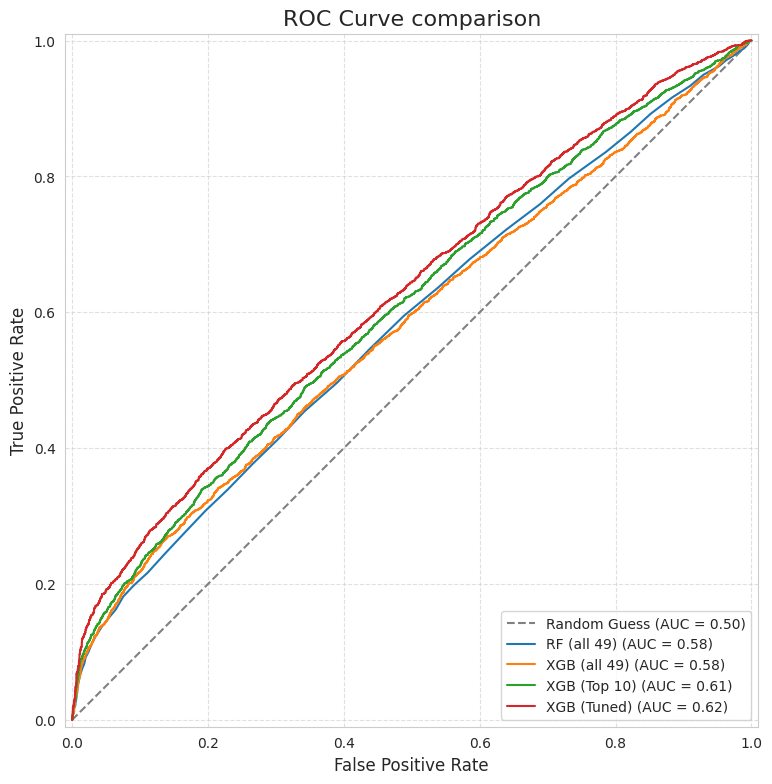

In [94]:
all_splits = list(tscv.split(X))
train_index, test_index = all_splits[-1]

X_train_49, X_test_49 = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

X_train_10, X_test_10 = X_exp2.iloc[train_index], X_exp2.iloc[test_index]


models_to_plot = {
    'RF (all 49)': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),

    'XGB (all 49)': xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'),

    'XGB (Top 10)': xgb.XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'),

    'XGB (Tuned)': xgb.XGBClassifier(
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                        eval_metric='logloss',
                        **best_params_from_exp4
                    )
}

roc_plot_results = []
plt.figure(figsize=(10, 9))
ax = plt.gca()

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess (AUC = 0.50)', color='gray')



for model_name, model in models_to_plot.items():
    start_time = time.time()

    if 'all 49' in model_name:
        model.fit(X_train_49, y_train)
        X_test_data = X_test_49
    else:
        model.fit(X_train_10, y_train)
        X_test_data = X_test_10

    RocCurveDisplay.from_estimator(
        model,
        X_test_data,
        y_test,
        name=model_name,
        ax=ax
    )

# 4. Finální úpravy grafu
plt.title('ROC Curve comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



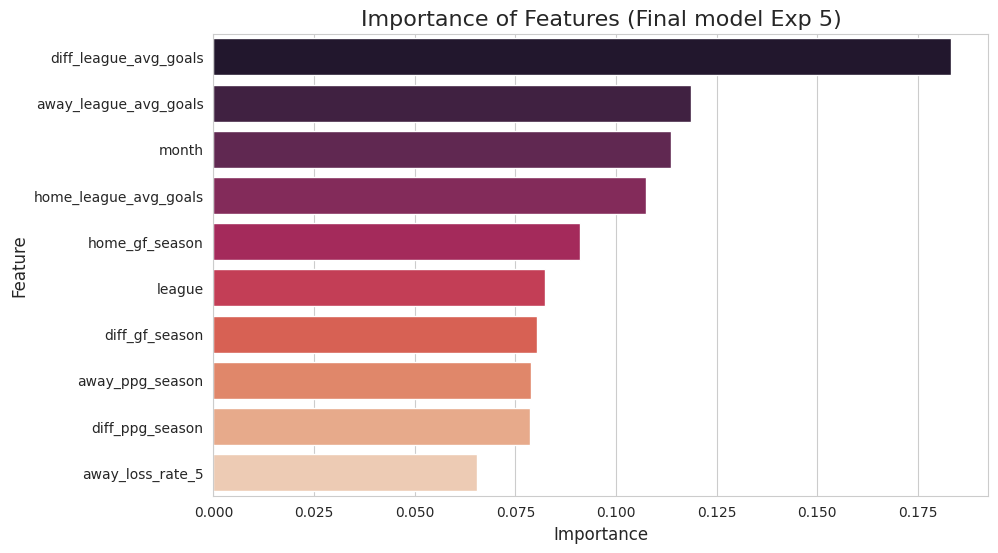

In [95]:
importances = current_model.feature_importances_
feature_names = X_exp2.columns

importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(
        x='Importance',
        y='Feature',
        data=importance_df,
        palette='rocket',
        hue='Feature',
        legend=False
    )

plt.title('Importance of Features (Final model Exp 5)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

#Final summary
This notebook documents an iterative process to develop the optimal predictive model for the target variable y_over25. The analysis proceeded through several key stages:

**Baseline Modeling (Exp 1)**: Establishing initial performance using all available features.

**Feature Selection (Exp 2 & 3):** Identifying and isolating the most predictive features to reduce noise.

**Hyperparameter Tuning (Exp 4):** Optimizing the best-performing model from the feature selection stage.

**Final Validation (Exp 5):** Confirming the performance of the tuned model using the established cross-validation strategy.

The final model, a tuned XGBoost classifier using a reduced set of 10 features, achieved a final validated Average ROC_AUC of 0.6241. This significantly outperformed both the initial baseline models and the models trained on the complete feature set.

In [96]:
all_results_df_list = []

if 'exp1_results_df' in locals():
    all_results_df_list.append(exp1_results_df)
if 'exp2_results_df' in locals():
    all_results_df_list.append(exp2_results_df)
if 'exp3_results_df' in locals():
    all_results_df_list.append(exp3_results_df)
if 'exp5_results_df' in locals():
    all_results_df_list.append(exp5_results_df)

baseline_data_list = [
    {
        'model': 'LinearSVM (Baseline)',
        'feature_set': 'baseline_CV',
        'Accuracy_mean': 0.553,
        'ROC_AUC_mean': 0.573,
        'Brier_Score_mean': 0.247,
    },
    {
        'model': 'RandomForest (Baseline)',
        'feature_set': 'baseline_CV',
        'Accuracy_mean': 0.548,
        'ROC_AUC_mean': 0.569,
        'Brier_Score_mean': 0.248,
    }
]
baseline_df = pd.DataFrame(baseline_data_list)
all_results_df_list.append(baseline_df)


final_summary_df = pd.concat(all_results_df_list, ignore_index=True)


metrics_to_show = ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC", "Brier_Score"]
columns_to_display = ['model', 'feature_set'] + [f"{m}_mean" for m in metrics_to_show]


final_summary_df = final_summary_df.sort_values(by='ROC_AUC_mean', ascending=False)


print(final_summary_df[columns_to_display].to_markdown(index=False, floatfmt=".4f"))


final_csv_path = os.path.join(output_path, 'final_summary_ALL_experiments.csv')
final_summary_df.to_csv(final_csv_path, index=False)

| model                   | feature_set      |   Accuracy_mean |   Precision_mean |   Recall_mean |   F1_Score_mean |   ROC_AUC_mean |   Brier_Score_mean |
|:------------------------|:-----------------|----------------:|-----------------:|--------------:|----------------:|---------------:|-------------------:|
| XGBoost_Tuned           | top_10_xgb_tuned |          0.5810 |           0.6224 |        0.4438 |          0.5181 |         0.6241 |             0.2343 |
| XGBoost                 | top_10_xgb       |          0.5695 |           0.5803 |        0.4998 |          0.5370 |         0.6032 |             0.2473 |
| RandomForest            | top_10_xgb       |          0.5690 |           0.5825 |        0.4811 |          0.5266 |         0.6001 |             0.2403 |
| RandomForest            | top_10_rf        |          0.5606 |           0.5737 |        0.4690 |          0.5158 |         0.5920 |             0.2421 |
| XGBoost                 | all_49           |          0.5614 |

# Key Findings
**Baseline vs. Feature Selection:** The initial XGBoost model on all 49 features (Avg. ROC_AUC: 0.5916) was outperformed by the model using only the Top 10 XGB-selected features (Avg. ROC_AUC: 0.6032). This confirmed that the full feature set contained noise, and feature selection was a critical step.

**Tuning vs. Validation: **Hyperparameter tuning (Exp 4) identified a strong parameter set (including a low learning_rate of 0.01 and a high max_depth of 10) with a promising score of 0.6217.

**Final Model: **Experiment 5 validated this tuned model, achieving a final Average ROC_AUC of 0.6241. This was the highest-performing model, demonstrating that both feature selection and hyperparameter tuning were essential for achieving the best result. The comparative ROC curve plot confirms this model's superior performance.

#Errors and Key Learnings
**Initial Error**: The initial models in Experiment 1 were hindered by noise from the full 49-feature set. The immediate performance gain in Experiment 2 (0.5916 -> 0.6032 for XGB) demonstrates that feature selection was a necessary step.

**Feature Set (Selection Method)**: Experiment 3 showed that not all feature selection methods yield equal results. The Top 10 list from RandomForest (Exp 3) actually made our best model (XGBoost) perform worse. Using the Top 10 list from XGBoost was the right choice.

**Suboptimal Parameters (Tuning):** The most significant performance gain was achieved through hyperparameter tuning. The default XGBoost model (AUC: 0.6032) was significantly outperformed by the tuned version (AUC: 0.6241).